In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
from scipy import stats

## Reconstruction processing

In [ ]:
# Region selection. Type WEST (60E-100E) or EAST (100E-140E)
region = "WEST"  # Change to "WEST" for western region

# Add buffer for region boundaries
buffer = 2  # degrees to add on all sides

# Region boundaries
REGIONS = {
    "WEST": {"lat_min": 65, "lat_max": 80, "lon_min": 60, "lon_max": 100},
    "EAST": {"lat_min": 65, "lat_max": 80, "lon_min": 100, "lon_max": 140}
}

# Apply buffer
region_bounds = REGIONS[region]
lat_min = region_bounds["lat_min"] - buffer
lat_max = region_bounds["lat_max"] + buffer
lon_min = region_bounds["lon_min"] - buffer
lon_max = region_bounds["lon_max"] + buffer

In [ ]:
# == DENROCHRONOLOGIES DATA UPLOAD ==
meta_df = pd.read_excel('dendrochronologies.xlsx',
                        sheet_name='l1', decimal=',')
filtered_meta = meta_df[(meta_df['lat'] >= lat_min) & (meta_df['lat'] <= lat_max) &
                        (meta_df['lon'] >= lon_min) & (meta_df['lon'] <= lon_max)]

# Load appropriate correlation file
corr_file = "chron_corr678_west.csv" if region == "WEST" else "chron_corr678_east.csv"
correlation_df = pd.read_csv(corr_file, sep=';', decimal=',')

# Process tree-ring data
rings_df = pd.read_excel('dendrochronologies.xlsx',
                         sheet_name='l2', decimal=',')
rings_long = rings_df.melt(id_vars=['Year'], var_name='ID', value_name='var')

# Merge and filter
merged_data = pd.merge(filtered_meta, rings_long, on='ID', how='inner')
final_data = merged_data[(merged_data['Year'] >= merged_data['fy']) &
                         (merged_data['Year'] <= merged_data['ly'])]

result_df = final_data[['ID', 'lat', 'lon', 'Year', 'var', 'fy', 'ly']]

# Filter by start year and series length
result_df = result_df[result_df['fy'] < 1800]

# Filter by correlation
result_df = result_df.merge(correlation_df[['ID', 'correlation']], on='ID', how='left')
result_df = result_df[result_df['correlation'] >= 0.45]

# Filter by minimum series length (10 years)
series_lengths = result_df.groupby('ID')['Year'].nunique()
valid_series = series_lengths[series_lengths >= 10].index
result_df = result_df[result_df['ID'].isin(valid_series)]

# Filter by variable (delete latewood density IDs)
result_df = result_df[~result_df['ID'].str.contains('t-crn', case=False)]
result_df = result_df[~result_df['ID'].str.contains('l-crn', case=False)]

# Save results
result_df.to_csv(f'dendrochronologies_filtered.csv', index=False, sep=';', decimal=',')
print(f"Processed {region} region: {result_df['ID'].nunique()} series, {len(result_df)} records")
print(result_df['ID'].unique())
print(result_df['correlation'].unique())

Processed WEST region: 25 series, 9047 records
['v_russ001-crn-noaa.txt' 'v_russ006-crn-noaa.txt'
 'v_russ007-crn-noaa.txt' 'v_russ009-crn-noaa.txt'
 'v_russ022x-crn-noaa.txt' 'v_russ023x-crn-noaa.txt'
 'v_russ026x-crn-noaa.txt' 'v_russ027x-crn-noaa.txt'
 'v_russ028x-crn-noaa.txt' 'v_russ029x-crn-noaa.txt'
 'v_russ030x-crn-noaa.txt' 'v_russ031x-crn-noaa.txt'
 'v_russ032x-crn-noaa.txt' 'v_russ033x-crn-noaa.txt'
 'v_russ034x-crn-noaa.txt' 'v_russ035x-crn-noaa.txt'
 'v_russ037x-crn-noaa.txt' 'v_russ094x-crn-noaa.txt'
 'v_russ097x-crn-noaa.txt' 'v_russ100x-crn-noaa.txt'
 'v_russ101x-crn-noaa.txt' 'v_russ122x-crn-noaa.txt'
 'v_russ123x-crn-noaa.txt' 'v_russ124x-crn-noaa.txt'
 'v_russ176x-crn-noaa.txt']
[0.533 0.514 0.522 0.499 0.601 0.673 0.753 0.764 0.649 0.755 0.51  0.628
 0.615 0.622 0.467 0.743 0.616 0.581 0.568 0.594 0.651 0.707 0.592 0.716
 0.515]


In [ ]:
# == DENROCHRONOLOGIES DATA + OTHER HIGH-FREQUENCY DATA COMBINATION ==

hf_df = pd.read_csv('highfreq_proxy.csv', sep=';', decimal=',')
dendro_df = pd.read_csv('dendrochronologies_filtered.csv', sep=';', decimal=',')

# High-frequency data region filtration
if region == "WEST":
    hf_df = hf_df.drop(columns=['Jacoby_tree_2000'], errors='ignore')
elif region == "EAST":
    hf_df = hf_df[['year', 'Jacoby_tree_2000']] if 'Jacoby_tree_2000' in hf_df.columns else pd.DataFrame(columns=['year'])

# Dendrochronology data processing
dendro_dict = {}
for id_val, group in dendro_df.groupby('ID'):
    group = group.rename(columns={'Year': 'year'})
    if not group.empty:
        dendro_dict[f'dendro_{id_val}'] = group.set_index('year')['var']

# Combination
combined_df_highfreq = hf_df.copy()
for name, series in dendro_dict.items():
    temp_df = series.reset_index().rename(columns={'var': name})
    combined_df_highfreq = pd.merge(combined_df_highfreq, temp_df, on='year', how='outer')

# Normalization
for col in combined_df_highfreq.columns:
    if col != 'year':
        vals = combined_df_highfreq[col].dropna()
        if len(vals) > 1:
            mean_val = vals.mean()
            std_val = vals.std()
            if std_val > 0:
                combined_df_highfreq.loc[combined_df_highfreq[col].notna(), col] = (combined_df_highfreq[col] - mean_val) / std_val

# Mistakes filtrations
for col in combined_df_highfreq.columns:
    if col != 'year':
        # Create a boolean mask for values outside [-4, 4]
        mask = (combined_df_highfreq[col] < -4) | (combined_df_highfreq[col] > 4)

        # Store original count of non-NaN values
        original_non_nan_count = combined_df_highfreq[col].notna().sum()

        # Replace identified values with np.nan
        combined_df_highfreq.loc[mask, col] = np.nan

        # Sort by year for proper interpolation
        combined_df_highfreq = combined_df_highfreq.sort_values('year')

        # NEW: Interpolate only if we have values to interpolate
        # Count NaN values that are not at the beginning or end
        if combined_df_highfreq[col].isna().any():
            # Find first and last non-NaN indices
            non_nan_indices = combined_df_highfreq[col].notna()
            if non_nan_indices.any():
                first_valid_idx = combined_df_highfreq[non_nan_indices].index[0]
                last_valid_idx = combined_df_highfreq[non_nan_indices].index[-1]

                # Apply interpolation ONLY between first and last valid values
                # Use forward fill then backward fill for isolated outliers
                combined_df_highfreq[col] = combined_df_highfreq[col].interpolate(method='linear', limit_direction='forward', limit_area='inside')

                # Also fill backward for any remaining isolated outliers
                combined_df_highfreq[col] = combined_df_highfreq[col].interpolate(method='linear', limit_direction='backward', limit_area='inside')

# Mean calculation - ensure we only use columns with actual data for each row
data_cols = [c for c in combined_df_highfreq.columns if c != 'year']
combined_df_highfreq['highfreq_proxy_mean'] = combined_df_highfreq[data_cols].mean(axis=1)

# Saving
combined_df_highfreq.to_csv(f'combined_highfreq_proxy.csv', sep=';', decimal=',', index=False)

In [ ]:
# == HIGH-FREQUENCY PROXY CALIBRATION ==
hf_df_combined = pd.read_csv('combined_highfreq_proxy.csv', sep=';', decimal=',')
instrumental_path = "instrumental_hadcrut_678mean_west.csv" if region == "WEST" else "instrumental_hadcrut_678mean_east.csv"
instrumental_df = pd.read_csv(instrumental_path, sep=';', decimal=',')
instrumental_df.columns = instrumental_df.columns.str.lower()

window = 100

# High and middle signal division
hf_df_combined['highfreq_proxy_mean_100'] = hf_df_combined['highfreq_proxy_mean'].rolling(window=window, center=True, min_periods=30).mean()
hf_df_combined['high_resid'] = hf_df_combined['highfreq_proxy_mean'] - hf_df_combined['highfreq_proxy_mean_100']

instrumental_df['mean_100'] = instrumental_df['mean'].rolling(window=window, center=True, min_periods=30).mean()
instrumental_df['resid'] = instrumental_df['mean'] - instrumental_df['mean_100']

# === Calibration ===

# Instrumental period
instr_period = (instrumental_df['year'] >= 1900) & (instrumental_df['year'] <= 2000)
highfreq_proxy_period = hf_df_combined['year'].between(1900, 2000)

# 1. Middle signal
middle_signal_proxy = hf_df_combined['highfreq_proxy_mean_100']
middle_signal_instr = instrumental_df['mean_100']

middle_mean_proxy = middle_signal_proxy[highfreq_proxy_period].mean()
middle_std_proxy = middle_signal_proxy[highfreq_proxy_period].std()
middle_mean_instr = middle_signal_instr[instr_period].mean()
middle_std_instr = middle_signal_instr[instr_period].std()

hf_df_combined['middle_signal_calibrated'] = (middle_signal_proxy - middle_mean_proxy) / middle_std_proxy * middle_std_instr + middle_mean_instr

# 2. High signal
high_signal_proxy = hf_df_combined['high_resid']
high_signal_instr = instrumental_df['resid']

high_mean_proxy = high_signal_proxy[highfreq_proxy_period].mean()
high_std_proxy = high_signal_proxy[highfreq_proxy_period].std()
high_mean_instr = high_signal_instr[instr_period].mean()
high_std_instr = high_signal_instr[instr_period].std()

hf_df_combined['high_signal_calibrated'] = (high_signal_proxy - high_mean_proxy) / high_std_proxy * high_std_instr + high_mean_instr

# 3. Summ signal
hf_df_combined['highfreq_mean_calibrated'] = hf_df_combined['middle_signal_calibrated'] + hf_df_combined['high_signal_calibrated']

hf_df_combined = hf_df_combined.drop(columns=['highfreq_proxy_mean_100', 'high_resid'])
hf_df_combined.to_csv(f'highfreq_proxy_calibrated.csv', sep=';', decimal=',', index=False)

In [ ]:
# == HIGH-FREQUENCY STABILISATION ==
hf_df_stabil = pd.read_csv('highfreq_proxy_calibrated.csv', sep=';', decimal=',')
hf_df_stabil.columns = hf_df_stabil.columns.str.lower()

# Proccessing
proxy_cols = [col for col in hf_df_stabil.columns if col not in ['year', 'highfreq_proxy_mean', 'highfreq_mean_calibrated', 'high_signal_calibrated', 'middle_signal_calibrated']]

# Mean correlation estimation
df_corr = hf_df_stabil.dropna(thresh=2)
if len(df_corr) > 0:
    corr_matrix = df_corr[proxy_cols].corr()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    r_values = upper_triangle.stack().dropna()
    r_mean = r_values.mean() if len(r_values) > 0 else 0.3
else:
    r_mean = 0.3

# n and n_eff calculation
hf_df_stabil['n'] = hf_df_stabil[proxy_cols].notna().sum(axis=1)
hf_df_stabil['n_eff'] = hf_df_stabil['n'] / (1 + (hf_df_stabil['n'] - 1) * r_mean)
n_inf = 1 / r_mean if r_mean > 0 else 10

# Dispersion correction
hf_df_stabil['correction_factor'] = np.sqrt(hf_df_stabil['n_eff'] / n_inf)
hf_df_stabil['correction_factor'] = hf_df_stabil['correction_factor'].clip(0.1, 10)
hf_df_stabil['highfreq_mean_calibrated_stabilized'] = hf_df_stabil['highfreq_mean_calibrated'] * hf_df_stabil['correction_factor']

# Saving
hf_df_stabil.to_csv('highfreq_proxy_calibrated_corrected.csv', sep=';', decimal=',', index=False)


In [ ]:
# == LOW-FREQUENCY PROXY CALIBRATION ==
instrumental_path = "instrumental_hadcrut_678mean_both.csv"
instrumental_df = pd.read_csv(instrumental_path, sep=';', decimal=',')
instrumental_df.columns = instrumental_df.columns.str.lower()

borehole = pd.read_csv('boreholes_pollack.csv', sep=';', decimal=',')
borehole.columns = borehole.columns.str.lower()

lowfreq_df = pd.read_csv('lowfreq_proxy.csv', sep=';', decimal=',')
lowfreq_df.columns = lowfreq_df.columns.str.lower()

pollen_df = pd.read_csv('pollen_herzschuh2021_interpolated.csv', sep=';', decimal=',')
pollen_df.columns = pollen_df.columns.str.lower()

lowfreq_df = pd.merge(lowfreq_df, pollen_df, on='year')

# Z-score and mean
for column in lowfreq_df.columns:
    if column != 'year':
        lowfreq_df[column] = (lowfreq_df[column] - lowfreq_df[column].mean()) / lowfreq_df[column].std()
data_cols = [col for col in lowfreq_df.columns if col != 'year']
lowfreq_df['lowfreq_proxy_mean'] = lowfreq_df[data_cols].mean(axis=1)

lf_df = lowfreq_df[['year', 'lowfreq_proxy_mean']].copy()

# === Instrumental data trend (1900–2000) ===
inst = instrumental_df[(instrumental_df['year'] >= 1900) & (instrumental_df['year'] <= 2000)].copy()
# Linear regression
if len(inst) > 1:
    slope_inst, intercept_inst, _, _, _ = stats.linregress(inst['year'], inst['mean'])
    # Trend of 100 years (1900-2000)
    inst_trend = slope_inst * 100  # Change for 100 years
else:
    inst_trend = inst['mean'].iloc[-1] - inst['mean'].iloc[0] if len(inst) > 0 else 0

# === Borehole trend (1900–2000)  ===
borehole_1900_2000 = borehole[(borehole['year'] >= 1900) & (borehole['year'] <= 2000)].copy()
borehole_trend = borehole_1900_2000['annual_anomaly'].iloc[-1] - borehole_1900_2000['annual_anomaly'].iloc[0] if len(borehole_1900_2000) > 0 else 0

# === Scaling of boreholes to instrumental trend ===
scaling = inst_trend / borehole_trend if borehole_trend != 0 else 1

# 1. Period for interpolation (с 1500 по 2000)
calib_years = np.arange(1500, 2001, 1)

# 2. Interpolation of boreholes for this years
borehole_interp = borehole.set_index('year').reindex(calib_years).interpolate(method='linear').reset_index()
borehole_interp.columns = ['year', 'borehole_interp']

# So, boreholes are interpolated (interp_borehole) and instrumental data is uploaded (instrumental)

# Mean borehole for 1900–2000
mean_borehole = borehole_1900_2000['annual_anomaly'].mean()
mean_instr = inst['mean'].mean()

# Calibration of boreholes by instrumental (GST - groung surface temperature)
borehole_interp['gst_calibrated'] = (borehole_interp['borehole_interp'] - mean_borehole) * scaling + mean_instr

# Statistics for instrumental and calibrated boreholes
mask = (lf_df['year'] >= 1900) & (lf_df['year'] <= 2000)

low_mean = lf_df.loc[mask, 'lowfreq_proxy_mean'].mean()
low_std = lf_df.loc[mask, 'lowfreq_proxy_mean'].std()

mean_b = np.mean(borehole_interp['gst_calibrated'])
std_b = np.std(borehole_interp['gst_calibrated'])

# Calibration of lowfreq_proxy_mean for the whole period
lf_df['lowfreq_mean_calibrated'] = (lf_df['lowfreq_proxy_mean'] - low_mean) / low_std * std_b + mean_b

# Saving
lowfreq_df.drop(columns=['lowfreq_proxy_mean'], errors='ignore', inplace=True)
lowfreq_df.to_csv("lowfreq_all_proxies.csv", sep=';', decimal=',', index=False)
lf_df.to_csv("lowfreq_proxy_calibrated.csv", sep=';', decimal=',', index=False)

In [ ]:
# == RECONSTRUCTION ==
instrumental_path = "instrumental_hadcrut_678mean_west.csv" if region == "WEST" else "instrumental_hadcrut_678mean_east.csv"
instrumental_df = pd.read_csv(instrumental_path, sep=';', decimal=',')
instrumental_df.columns = instrumental_df.columns.str.lower()

highfreq = pd.read_csv('highfreq_proxy_calibrated_corrected.csv', sep=';', decimal=',')
lowfreq = pd.read_csv('lowfreq_proxy_calibrated.csv', sep=';', decimal=',')

reconstruction_final = pd.DataFrame({
    'year': highfreq['year'],
    'highfreq_serie': highfreq['highfreq_mean_calibrated_stabilized'],
    'lowfreq_serie': lowfreq['lowfreq_mean_calibrated']
})

# Mean for high- and low-frequency series
reconstruction_final['full_reconstruction'] = (reconstruction_final['highfreq_serie'] + reconstruction_final['lowfreq_serie']) / 2

# == Final Calibration ==
# Crop for calibration period (1850-2000)
mask_recon = (reconstruction_final['year'] >= 1850) & (reconstruction_final['year'] <= 2000)
mask_instr = (instrumental_df['year'] >= 1850) & (instrumental_df['year'] <= 2000)
recon_filtered = reconstruction_final.loc[mask_recon, 'full_reconstruction']
instr_filtered = instrumental_df.loc[mask_instr, 'mean']

# Statistics
mean_recon = recon_filtered.mean()
std_recon = recon_filtered.std()
mean_instr = instr_filtered.mean()
std_instr = instr_filtered.std()

# Scaling
reconstruction_calibrated = (reconstruction_final['full_reconstruction'] - mean_recon) / std_recon * std_instr + mean_instr
reconstruction_final['reconstruction_calibrated'] = reconstruction_calibrated

# Saving
reconstruction_final.to_csv(f"reconstruction_final_{region}.csv", index=False, sep=';', decimal=',')

##Graphics

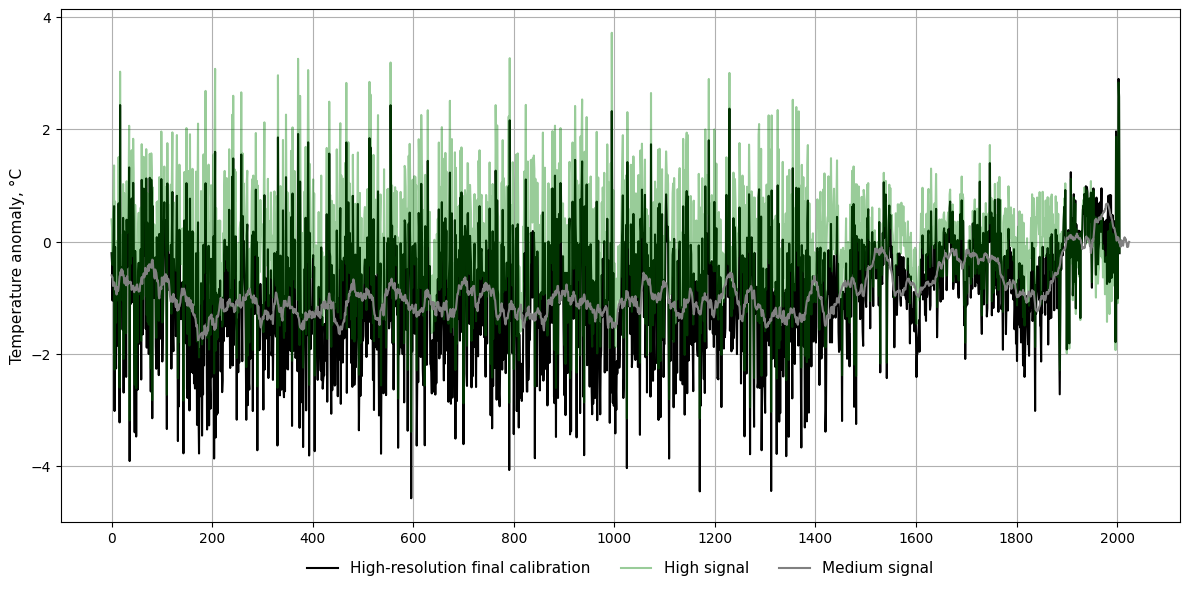

In [ ]:
# == High-frequency calibration graph ==
plt.figure(figsize=(12, 6))
plt.plot(hf_df_combined['year'], hf_df_combined['highfreq_mean_calibrated'], label='High-resolution final calibration', color='black')
plt.plot(hf_df_combined['year'], hf_df_combined['high_signal_calibrated'], label='High signal', color='green', alpha=0.4)
plt.plot(hf_df_combined['year'], hf_df_combined['middle_signal_calibrated'], label='Medium signal', color='grey')
n_ticks = 11
xticks_positions = np.linspace(lf_df['year'].min(), lf_df['year'].max(), n_ticks, dtype=int)
xticks_positions = [round(x / 200) * 200 for x in xticks_positions]

plt.xticks(xticks_positions)
plt.ylabel("Temperature anomaly, °C", fontsize=11)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

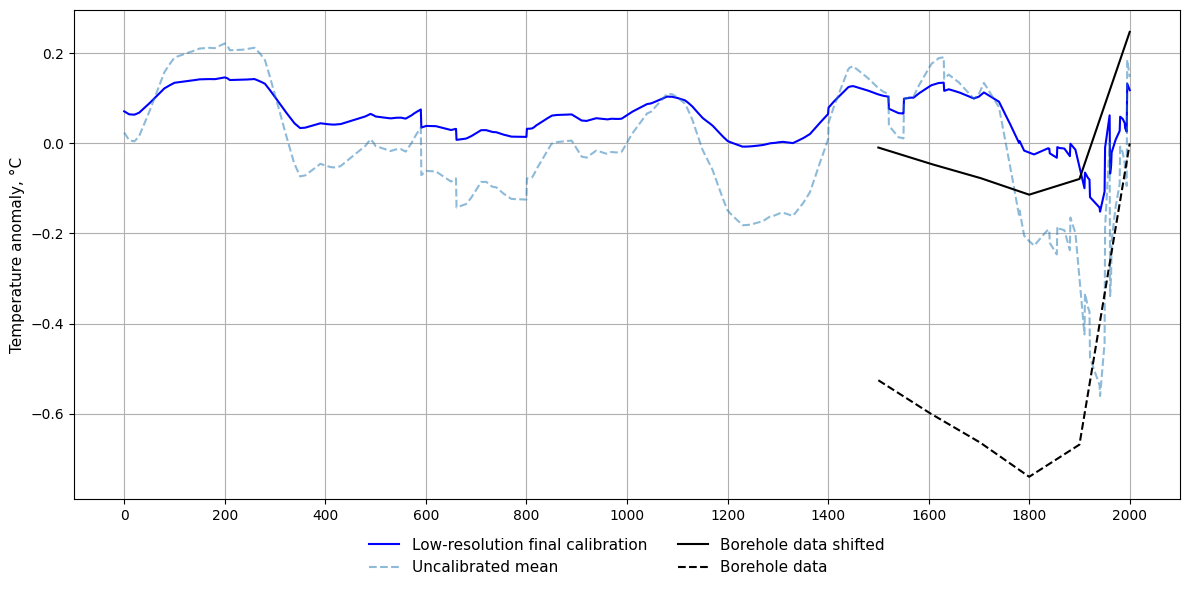

In [ ]:
# == Low-frequency calibration graph ==
plt.figure(figsize=(12, 6))
plt.plot(lf_df['year'], lf_df['lowfreq_mean_calibrated'], label='Low-resolution final calibration', color='blue')
plt.plot(lf_df['year'], lf_df['lowfreq_proxy_mean'], label='Uncalibrated mean', alpha=0.5, linestyle='--')
plt.plot(borehole_interp['year'], borehole_interp['gst_calibrated'], color='black', label='Borehole data shifted')
plt.plot(borehole_interp['year'], borehole_interp['borehole_interp'], color='black', linestyle='--', label='Borehole data')

n_ticks = 11
xticks_positions = np.linspace(lf_df['year'].min(), lf_df['year'].max(), n_ticks, dtype=int)
xticks_positions = [round(x / 200) * 200 for x in xticks_positions]

plt.xticks(xticks_positions)
plt.ylabel("Temperature anomaly, °C", fontsize=11)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

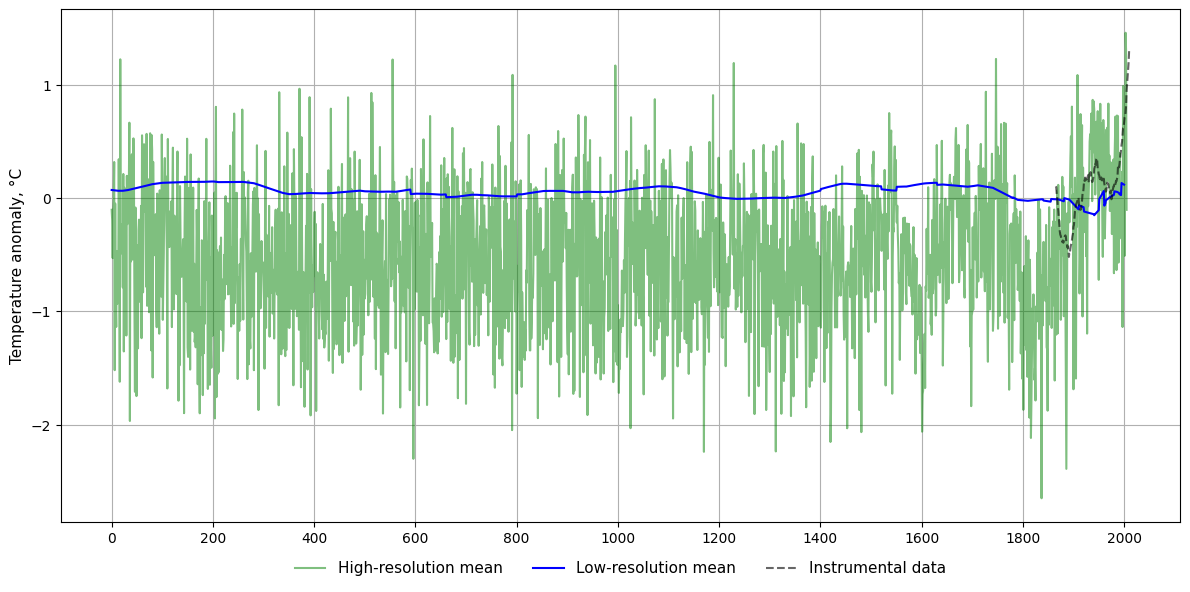

In [ ]:
# == Both series comparasion graph ==
instrumental_path = "instrumental_hadcrut_678mean_west.csv" if region == "WEST" else "instrumental_hadcrut_678mean_east.csv"
instrumental_df = pd.read_csv(instrumental_path, sep=';', decimal=',')
instrumental_df.columns = instrumental_df.columns.str.lower()
instrumental_df['mean_30'] = instrumental_df['mean'].rolling(window=30, center=True, min_periods=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(hf_df_stabil['year'], hf_df_stabil['highfreq_mean_calibrated_stabilized'], label='High-resolution mean', color='green', alpha=0.5)
plt.plot(lf_df['year'], lf_df['lowfreq_mean_calibrated'], label='Low-resolution mean', color='blue')
plt.plot(instrumental_df['year'], instrumental_df['mean_30'], label='Instrumental data', color='black', linestyle='--', alpha=0.6)

n_ticks = 11
xticks_positions = np.linspace(lf_df['year'].min(), lf_df['year'].max(), n_ticks, dtype=int)
xticks_positions = [round(x / 200) * 200 for x in xticks_positions]

plt.xticks(xticks_positions)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False, fontsize=11)
#plt.xlabel("Year")
plt.ylabel("Temperature anomaly, °C", fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

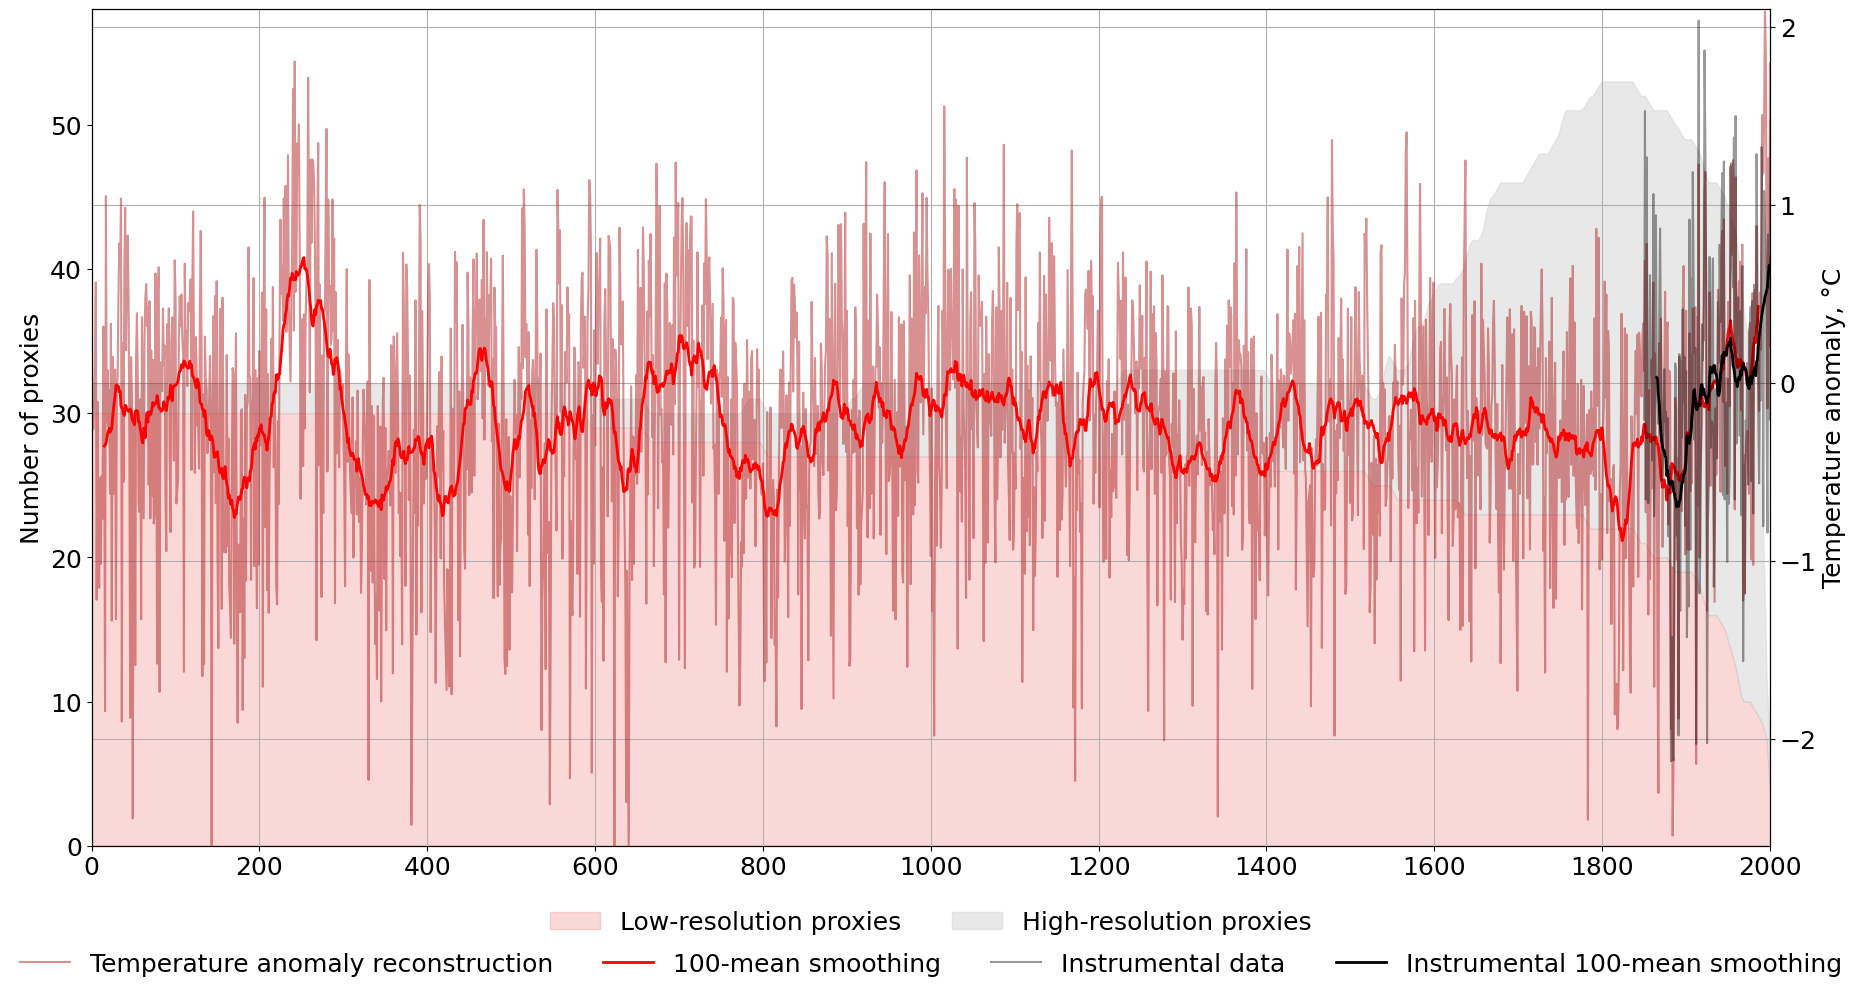

In [ ]:
# == Final reconstruction graph ==
window = 30

highfreq = pd.read_csv('combined_highfreq_proxy.csv', sep=';', decimal=',')
lowfreq = pd.read_csv('lowfreq_all_proxies.csv', sep=';', decimal=',')

# 1. Proxy count for highfreq
highfreq_proxy_cols = [col for col in highfreq.columns if col != 'year']
high_counts = pd.DataFrame()

for year in highfreq['year'].unique():
    # For each year count not NaN values
    year_data = highfreq[highfreq['year'] == year]
    proxy_count = year_data[highfreq_proxy_cols].notna().sum().sum()
    high_counts = pd.concat([high_counts, pd.DataFrame({'year': [year], 'high_n': [int(proxy_count)]})])

# 2. Proxy count for lowfreq
lowfreq_proxy_cols = [col for col in lowfreq.columns if col != 'year']
low_counts = pd.DataFrame()

for year in lowfreq['year'].unique():
    # For each year count not NaN values
    year_data = lowfreq[lowfreq['year'] == year]
    proxy_count = year_data[lowfreq_proxy_cols].notna().sum().sum()
    low_counts = pd.concat([low_counts, pd.DataFrame({'year': [year], 'low_n': [int(proxy_count)]})])

# 3. Merge all counts
proxy_counts = pd.merge(high_counts, low_counts, on='year', how='outer').fillna(0)

proxy_counts['high_n'] = proxy_counts['high_n'].astype(int)
proxy_counts['low_n'] = proxy_counts['low_n'].astype(int)
proxy_counts['total_n'] = proxy_counts['high_n'] + proxy_counts['low_n']

# Sort by year
proxy_counts = proxy_counts.sort_values('year').reset_index(drop=True)

# Smoothing and instrumental data
reconstruction_final['reconstruction_calibrated_smoothed'] = reconstruction_final['reconstruction_calibrated'].rolling(window=window, center=True, min_periods=30).mean()

instrumental_path = "instrumental_hadcrut_678mean_west.csv" if region == "WEST" else "instrumental_hadcrut_678mean_east.csv"
instrumental_df = pd.read_csv(instrumental_path, sep=';', decimal=',')
instrumental_df.columns = instrumental_df.columns.str.lower()
instrumental_df['mean_smoothed'] = instrumental_df['mean'].rolling(window=window, center=True, min_periods=30).mean()

# Graphics
fig, ax1 = plt.subplots(1, 1, figsize=(20, 10))

# Proxy count
# Smooth the proxy counts to remove spikes
proxy_counts_smoothed = proxy_counts.copy()
proxy_counts_smoothed['low_n'] = proxy_counts_smoothed['low_n'].rolling(window=10, center=True, min_periods=1).mean()
proxy_counts_smoothed['high_n'] = proxy_counts_smoothed['high_n'].rolling(window=10, center=True, min_periods=1).mean()
proxy_counts_smoothed['total_n'] = proxy_counts_smoothed['total_n'].rolling(window=10, center=True, min_periods=1).mean()


ax1.fill_between(proxy_counts_smoothed['year'], 0, proxy_counts_smoothed['low_n'],
                 color='lightcoral', alpha=0.3, label='Low-resolution proxies', zorder=1)
ax1.fill_between(proxy_counts_smoothed['year'], proxy_counts_smoothed['low_n'], proxy_counts_smoothed['total_n'],
                 color='lightgray', alpha=0.5, label='High-resolution proxies', zorder=1)

ax1.set_ylabel('Number of proxies', color='k', y=0.5, fontsize=18) # Adjusted label position
ax1.tick_params(axis='y', labelcolor='k', labelsize=18)
ax1.tick_params(axis='x', labelcolor='k', labelsize=18)
ax1.set_ylim(0, proxy_counts_smoothed['total_n'].max() + 5) # Remove or adjust this line
ax1.grid(True, axis='x') # Grid for years


ax2 = ax1.twinx()
# Temperature
ax2.plot(reconstruction_final['year'], reconstruction_final['reconstruction_calibrated'], label='Temperature anomaly reconstruction', color='firebrick', alpha=0.5, zorder=2)
ax2.plot(reconstruction_final['year'], reconstruction_final['reconstruction_calibrated_smoothed'], label='100-mean smoothing', color='red', linewidth=2, zorder=2)
ax2.plot(instrumental_df['year'], instrumental_df['mean'], label='Instrumental data', color='k', alpha=0.4, zorder=2)
ax2.plot(instrumental_df['year'], instrumental_df['mean_smoothed'], label='Instrumental 100-mean smoothing', color='k', linewidth=2, zorder=2)
ax2.set_ylabel('Temperature anomaly, °C', fontsize=18)
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylim(-2.6,2.1)
ax2.set_xlim(0, 2000) # Set x-axis limit
ax2.grid(True, axis='y') # Grid for temperature


# Merge legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Create two legend instances
legend1 = ax1.legend(lines1, labels1, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(lines1), frameon=False, fontsize=18)
legend2 = ax1.legend(lines2, labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(lines2), frameon=False, fontsize=18)

# Add the first legend manually to the figure
ax1.add_artist(legend1)

n_ticks = 11
xticks_positions = np.linspace(lf_df['year'].min(), lf_df['year'].max(), n_ticks, dtype=int)
xticks_positions = [round(x / 200) * 200 for x in xticks_positions]

plt.xticks(xticks_positions, fontsize=19)
#plt.xlabel('Year', fontsize=14)
#plt.xticks(fontsize=19)
#plt.grid(axis='x')
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

## Some stats

In [ ]:
from scipy.stats import pearsonr

mask_recon = (reconstruction_final['year'] >= 1850) & (reconstruction_final['year'] <= 2000)
mask_instr = (instrumental_df['year'] >= 1850) & (instrumental_df['year'] <= 2000)


recon_filtered = reconstruction_final.loc[mask_recon, 'reconstruction_calibrated']
instr_filtered = instrumental_df.loc[mask_instr, 'mean']

# Statistics
mean_recon = recon_filtered.mean()
std_recon = recon_filtered.std()
mean_instr = instr_filtered.mean()
std_instr = instr_filtered.std()
print(mean_recon, std_recon, mean_instr, std_instr)


r, p = pearsonr(recon_filtered.values, instr_filtered.values)

print(r)

-0.06209010794701988 0.8322910430641346 -0.06209010794701985 0.8322910430641346
0.7603453844899069
